# COM328 - Manifold Learning and Clustering Methods
##### notebook code (C) 2025-2026 Timothy James Becker
## ITSL CH12: Unsupervised Methods ++ (other more advanced methods not in the book)

<img src="https://upload.wikimedia.org/wikipedia/commons/f/f5/GaussianScatterPCA.svg" width=400>

When we no longer have the $Y$ variable we want to predict and yet we are looking for patterns inside our data, this can be thought of as exploratory data analysis, unsupervised learning, manifold learning (when you are learning a pattern of the vairables, IE the manifold), clustering, simulairity search, and many other names (depending on the application or goal). We use some parts of our text CH12 (PCA) and then some parts of papers that offer best in class non-linear manifold learning (T-SNE, UMAP) with some examples of each type on the MNIST input data from sklearn.

In [28]:
%pip install umap-learn==0.5.6

  Using cached numba-0.65.0.tar.gz (2.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached llvmlite-0.47.0.tar.gz (193 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for numba (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [854 lines of output]
      /private/var/folders/bb/g3jnl_p57d11fvwjyxpcpwhc0000gn/T/pip-build-env-13mec8c0/overlay/lib/python3.13/site-packages/setuptools/dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ***********************************************************************

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import offsetbox
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import numba
import umap

In [6]:
def plot_embedding(X, labels=None, title=None): #some ploting code we can use for this section
    fig, ax = plt.subplots()
    plt.figure(figsize=(12,10))
    X = MinMaxScaler().fit_transform(X)
    for digit in digits.target_names:
        ax.scatter(
            *X[y == digit].T,
            marker=f"${digit}$",
            s=60,
            color=(plt.cm.Dark2(digit) if labels is None else plt.cm.nipy_spectral(labels[y == digit] / 10)),
            alpha=0.425,
            zorder=2)
    shown_images = np.array([[1.0, 1.0]])  # just something big
    for i in range(X.shape[0]):
        # plot every digit on the embedding
        # show an annotation box for a group of digits
        dist = np.sum((X[i] - shown_images) ** 2, 1)
        if np.min(dist) < 4e-3:
            # don't show points that are too close
            continue
        shown_images = np.concatenate([shown_images, [X[i]]], axis=0)
    ax.set_title(title)
    ax.axis("off")

In [7]:
#import the handwritten digits dataset
digits = load_digits(n_class=6)
X, y = digits.data, digits.target
n_samples, n_features = X.shape
n_neighbors = 30

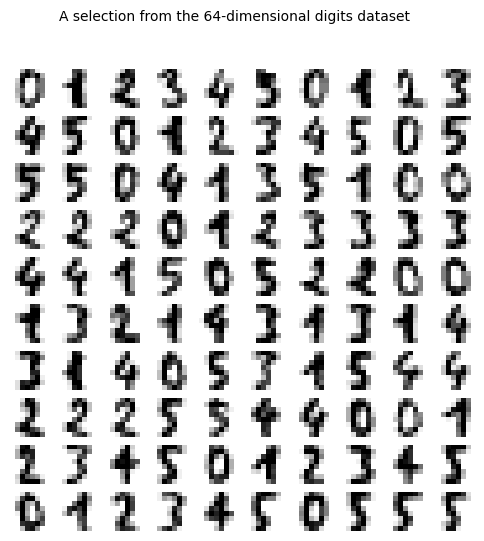

In [8]:
#look at the data in terms of some random sampling
fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(X[idx].reshape((8, 8)), cmap=plt.cm.binary)
    ax.axis("off")
_ = fig.suptitle("A selection from the 64-dimensional digits dataset", fontsize=10)

### Principle Component Analysis (PCA)
A simple form of dimension reduction (or exploratory data analysis) that looks for correlations between pairs of column variables in order selection the most prominent combinations (IE the linear combinations that maximize the variance). Mathmatically we can describe the first priciple component as:

$Z_1 = \phi_{11}X_1+\phi_{21}X_2+ ... + \phi_{p1}X_1$ (12.1)

which we find using the maximization here:

$\displaystyle\max_{\phi_{11},...,\phi_{p1}}^{} \left\{ \frac{1}{n} \displaystyle\sum_{i=1}^{n} \left(  \displaystyle\sum_{j=1}^{p} \phi_{j1}x_{ij} \right) \right\}$

In [30]:
#some sklearn PCA code here and a plot?
pca     = PCA(n_components=64, svd_solver='full')
pca.fit(X)
total_variance = np.sum(pca.explained_variance_)
x = 0.0
m = 0.5
i = 0
while i<pca.n_components and x<m:
    x += pca.explained_variance_[i]/total_variance
    i += 1
i

4

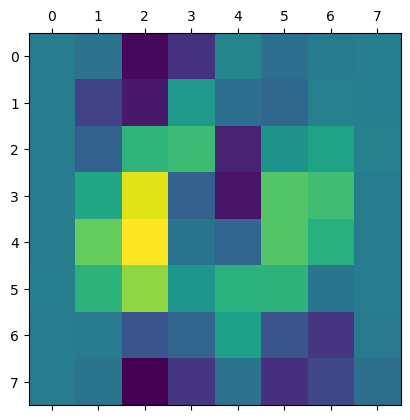

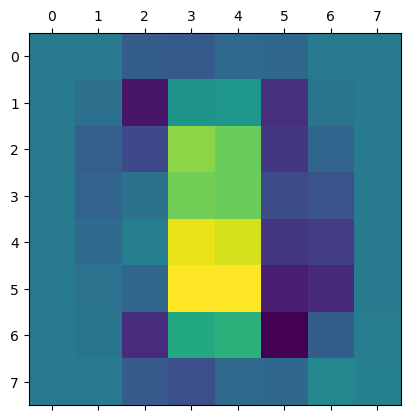

In [13]:
pca_1 = pca.components_[0].T
pca_2 = pca.components_[1].T

plt.matshow(pca_1.reshape(8,8))
plt.matshow(pca_2.reshape(8,8))


In [34]:
pca.explained_variance_[0]/total_variance + pca.explained_variance_[1]/total_variance

np.float64(0.35760174336189776)

In [42]:
id1 = np.where(np.abs(pca_1)<0.01)[0]
id2 = np.where(np.abs(pca_2)<0.01)[0]
set(id1).intersection(set(id2))

{np.int64(0),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(15),
 np.int64(16),
 np.int64(23),
 np.int64(24),
 np.int64(31),
 np.int64(32),
 np.int64(39),
 np.int64(40),
 np.int64(47),
 np.int64(48),
 np.int64(56)}

In [46]:
id1 = np.where(np.abs(pca_1)>0.1)[0]
id2 = np.where(np.abs(pca_2)>0.1)[0]
set(id1).intersection(set(id2))

{np.int64(10),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(28),
 np.int64(29),
 np.int64(37),
 np.int64(38),
 np.int64(44),
 np.int64(45)}

### T-distributed Stochastic Neighbor Embedding [T-SNE](https://jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf)

Given a set of $N$ high-dimensional objects ${\displaystyle \mathbf {x} _{1},\dots ,\mathbf {x} _{N}}$ , t-SNE first computes probabilities ${\displaystyle p_{ij}}$ that are proportional to the similarity of objects ${\displaystyle \mathbf {x} _{i}}$ and ${\displaystyle \mathbf {x} _{j}}$, as follows:

For ${\displaystyle i\neq j}$, define:

${\displaystyle p_{j\mid i}={\frac {\exp(-\lVert \mathbf {x} _{i}-\mathbf {x} _{j}\rVert ^{2}/2\sigma _{i}^{2})}{\sum _{k\neq i}\exp(-\lVert \mathbf {x} _{i}-\mathbf {x} _{k}\rVert ^{2}/2\sigma _{i}^{2})}}}$

and set ${\displaystyle p_{i\mid i}=0}$. Note the above denominator ensures ${\displaystyle \sum _{j}p_{j\mid i}=1}$ for all ${\displaystyle i}$. 

Now define:

${\displaystyle p_{ij}={\frac {p_{j\mid i}+p_{i\mid j}}{2N}}}$

This is motivated because ${\displaystyle p_{i}}$ and ${\displaystyle p_{j}}$ from the N samples are estimated as 1/N, so the conditional probability can be written as ${\displaystyle p_{i\mid j}=Np_{ij}}$ and ${\displaystyle p_{j\mid i}=Np_{ji}}$ . Since ${\displaystyle p_{ij}=p_{ji}}$, you can obtain previous formula.

Also note that ${\displaystyle p_{ii}=0}$ and ${\displaystyle \sum _{i,j}p_{ij}=1}$.

The bandwidth of the Gaussian kernels ${\displaystyle \sigma _{i}}$ is set in such a way that the entropy of the conditional distribution equals a predefined entropy using the bisection method. As a result, the bandwidth is adapted to the density of the data: smaller values of ${\displaystyle \sigma _{i}}$ are used in denser parts of the data space. The entropy increases with the perplexity of this distribution ${\displaystyle P_{i}}$; this relation is seen as:

${\displaystyle Perp(P_{i})=2^{H(P_{i})}}$

where ${\displaystyle H(P_{i})}$ is the Shannon entropy ${\displaystyle H(P_{i})=-\sum _{j}p_{j|i}\log _{2}p_{j|i}}$ 

t-SNE aims to learn a ${\displaystyle d}$-dimensional map ${\displaystyle \mathbf {y} _{1},\dots ,\mathbf {y} _{N}}$ (with ${\displaystyle \mathbf {y} _{i}\in \mathbb {R} ^{d}}$ and ${\displaystyle d}$ typically chosen as 2 or 3) that reflects the similarities ${\displaystyle p_{ij}}$ as well as possible. To this end, it measures similarities ${\displaystyle q_{ij}}$ between two points in the map ${\displaystyle \mathbf {y} _{i}}$ and ${\displaystyle \mathbf {y} _{j}}$, using a very similar approach. Specifically, for ${\displaystyle i\neq j}$, define ${\displaystyle q_{ij}}$ as

${\displaystyle q_{ij}={\frac {(1+\lVert \mathbf {y} _{i}-\mathbf {y} _{j}\rVert ^{2})^{-1}}{\sum _{k}\sum _{l\neq k}(1+\lVert \mathbf {y} _{k}-\mathbf {y} _{l}\rVert ^{2})^{-1}}}}$

and set ${\displaystyle q_{ii}=0}$. Herein a heavy-tailed Student t-distribution (with one-degree of freedom, which is the same as a Cauchy distribution) is used to measure similarities between low-dimensional points in order to allow dissimilar objects to be modeled far apart in the map.

The locations of the points ${\displaystyle \mathbf {y} _{i}}$ in the map are determined by minimizing the (non-symmetric) Kullback–Leibler divergence of the distribution ${\displaystyle P}$ from the distribution ${\displaystyle Q}$, that is:

${\displaystyle \mathrm {KL} \left(P\parallel Q\right)=\sum _{i\neq j}p_{ij}\log {\frac {p_{ij}}{q_{ij}}}}$

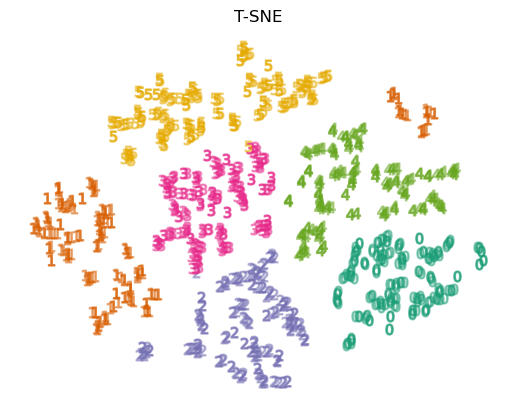

<Figure size 1200x1000 with 0 Axes>

In [47]:
#some sklearn TSNE
tsne     = TSNE(n_components=2,learning_rate='auto',init='random', perplexity=3.0)
tsne_emb = tsne.fit_transform(X)
plot_embedding(tsne_emb,None,'T-SNE')

### Uniform Manifold Aproximation: [UMAP](https://arxiv.org/pdf/1802.03426)
*advanced Math concepts from Category Theory, Probability, Linear Algebra, Multivariate Calculus and Computational Geometry

##### Graph Construction

The first phase of UMAP can be thought of as the construction of a weighted k-neighbour graph. Let $X  = \{x_1,\ldots,x_N\}$ be the input dataset, with a metric (or dissimilarity measure) $d:X\times X \to \mathbb{R}_{\geq 0}$. Given an input hyper-parameter $k$, for each $x_i$ we compute the set $\{x_{i_1},\ldots, x_{i_k}\}$ of the $k$ nearest neighbors of $x_i$ under the metric $d$. This computation can be performed via any nearest neighbour or approximate nearest neighbour search algorithm.  For the purposes of our UMAP implemenation we prefer to use the nearest neighbor descent algorithm of \cite{DongNearestNeighbour}.

For each $x_i$ we will define $\rho_i$ and $\sigma_i$. Let 

$rho_i = \min \{ d(x_i, x_{i_j}) \mid 1\leq j\leq k, d(x_i, x_{i_j}) > 0\}$,

and set $\sigma_i$ to be the value such that

$\sum_{j=1}^k \exp\left(\frac{-\max(0, d(x_i, x_{i_j}) - \rho_i)}{\sigma_i}\right) = \log_2(k)$.

The selection of $\rho_i$ derives from the local-connectivity constraint. In particular it ensures that $x_i$ connects to at least one other data point with an edge of weight 1; this is equivalent to the resulting fuzzy simplicial set being locally connected at $x_i$. In practical terms this significantly improves the representation on very high dimensional data where other algorithms such as t-SNE begin to suffer from the curse of dimensionality.

The selection of $\sigma_i$ corresponds to (a smoothed) normalisation factor, defining the Riemannian metric local to the point $x_i$.

We can now define a weighted directed graph $\bar{G} = (V, E, w)$. The vertices $V$ of $\bar{G}$ are simply the set $X$. We can then form the set of directed edges $E = \{(x_i, x_{i_j}) \mid 1\leq j\leq k, 1\leq i\leq N\}$, and define the weight function $w$ by setting

$w((x_i, x_{i_j})) = \exp\left(\frac{-\max(0, d(x_i, x_{i_j}) - \rho_i)}{\sigma_i}\right)$.

For a given point $x_i$ there exists an induced graph of $x_i$ and outgoing edges incident on $x_i$. This graph is the 1-skeleton of the fuzzy simplicial set associated to the metric space local to $x_i$ where the local metric is defined in terms of $\rho_i$ and $\sigma_i$. The weight associated to the edge is the membership strength of the corresponding 1-simplex within the fuzzy simplicial set.

Let $A$ be the weighted adjacency matrix of $\bar{G}$, and consider the symmetric matrix

$B = A + A^\top - A \circ A^\top$,

where $\circ$ is the Hadamard (or pointwise) product. This formula derives from the use of the probabilistic t-conorm used in unioning the fuzzy simplicial sets. If one interprets the value of $A_{ij}$ as the probability that the directed edge from $x_i$ to $x_j$ exists, then $B_{ij}$ is the probability that at least one of the two directed edges (from $x_i$ to $x_j$ and from $x_j$ to $x_i$) exists. The UMAP graph $G$ is then an undirected weighted graph whose adjacency matrix is given by $B$.

##### Graph layout

In practice UMAP uses a force directed graph layout algorithm in low dimensional space.  A force directed graph layout utilizes of a set of attractive forces applied along edges and a set of repulsive forces applied among vertices.  Any force directed layout algorithm requires a description of both the attractive and repulsive forces.  The algorithm proceeds by iteratively applying attractive and repulsive forces at each edge or vertex.  This amounts to a non-convex optimization problem. Convergence to a local minima is guaranteed by slowly decreasing the attractive and repulsive forces in a similar fashion to that used in simulated annealing.  

In UMAP the attractive force between two vertices $i$ and
$j$ at coordinates $\mathbf{y_i}$ and $\mathbf{y_j}$ respectively, is determined by:


$\frac{-2ab \|\mathbf{y_i} - \mathbf{y_j} \|_2^
{2\left(b - 1\right)}}{1 + \|\mathbf{y_i} - \mathbf{y_j} \|_2^2}  w((x_i, x_j)) \left(\mathbf{y_i - y_j}\right)$

where $a$ and $b$ are hyper-parameters.

Repulsive forces are computed via sampling due to computational constraints.  Thus, whenever an attractive force is applied to an edge, one of that edge's vertices is repulsed by a sampling of other vertices.  The repulsive force is given by


$\frac{2b}{\left(\epsilon + \|\mathbf{y_i} - \mathbf{y_j} \|_2^2\right)
\left(1 + a\|\mathbf{y_i} - \mathbf{y_j} \|_2^{2b}\right)}
\left(1 - w((x_i, x_j))\right)\left(\mathbf{y_i - y_j}\right).$

$\epsilon$ is a small number to prevent division by zero (0.001 in the current implementation).

The algorithm can be initialized randomly but in practice, since the symmetric Laplacian of the graph $G$ is a discrete approximation of the Laplace-Beltrami operator of the manifold, we can use a spectral layout to initialize the embedding.  This provides both faster convergence and greater stability within the algorithm.

The forces described above are derived from gradients optimising the edge-wise cross-entropy between the weighted graph $G$, and an equivalent weighted graph $H$ constructed from the points $\{\mathbf{y_i}\}_{i=1..N}$. That is, we are seeking to position points $y_i$ such that the weighted graph induced by those points most closely approximates the graph $G$, where we measure the difference between weighted graphs by the total cross entropy over all the edge existence probabilities. Since the weighted graph $G$ captures the topology of the source data, the equivalent weighted graph $H$ constructed from the points $\{\mathbf{y_i}\}_{i=1..N}$ matches the topology as closely as the optimization allows, and thus provides a good low dimensional representation of the overall topology of the data.


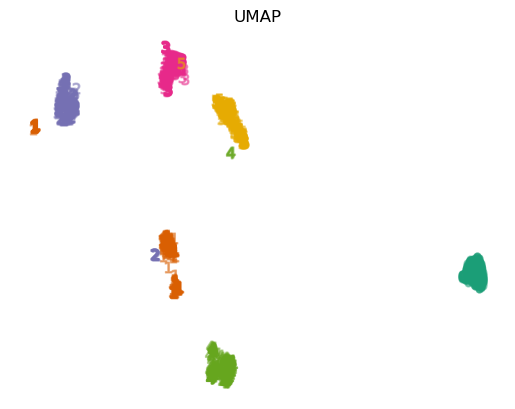

<Figure size 1200x1000 with 0 Axes>

In [52]:
#some umap-learn code here
import umap
_umap     = umap.UMAP(n_components=2,min_dist=0.0,n_neighbors=50)
_umap_emb = _umap.fit_transform(X)
plot_embedding(_umap_emb,None,'UMAP')

### Clustering (Hierarchical and KNN)

Clustering is the process of using the data directly (or more often using a reduced dimension from one of the above emmbedings) to assign clusters (a labeling/grouping of data rows that are similiar or closer in metric distance)

#### [Agglomerative Clustering](https://en.wikipedia.org/wiki/Hierarchical_clustering)

Bottom up method builds the hierarchy from the individual elements by progressively merging clusters. In our example, we have six elements ${a} {b} {c} {d} {e}$ and ${f}$. The first step is to determine which elements to merge in a cluster. Usually, we want to take the two closest elements, according to the chosen distance.

Optionally, one can also construct a distance matrix at this stage, where the number in the i-th row j-th column is the distance between the i-th and j-th elements. Then, as clustering progresses, rows and columns are merged as the clusters are merged and the distances updated. This is a common way to implement this type of clustering, and has the benefit of caching distances between clusters. A simple agglomerative clustering algorithm is described in the single-linkage clustering page; it can easily be adapted to different types of linkage (see below).

Suppose we have merged the two closest elements b and c, we now have the following clusters {a}, {b, c}, {d}, {e} and {f}, and want to merge them further. To do that, we need to take the distance between {a} and {b c}, and therefore define the distance between two clusters. Usually the distance between two clusters ${\displaystyle {\mathcal {A}}}$ and ${\displaystyle {\mathcal {B}}}$ is one of the following:

The maximum distance between elements of each cluster (also called complete-linkage clustering):

${\displaystyle \max\{\,d(x,y):x\in {\mathcal {A}},\,y\in {\mathcal {B}}\,\}}$

The minimum distance between elements of each cluster (also called single-linkage clustering):

${\displaystyle \min\{\,d(x,y):x\in {\mathcal {A}},\,y\in {\mathcal {B}}\,\}}$

The mean distance between elements of each cluster (also called average linkage clustering, used e.g. in UPGMA):

${\displaystyle {1 \over {|{\mathcal {A}}|\cdot |{\mathcal {B}}|}}\sum _{x\in {\mathcal {A}}}\sum _{y\in {\mathcal {B}}}d(x,y)}$

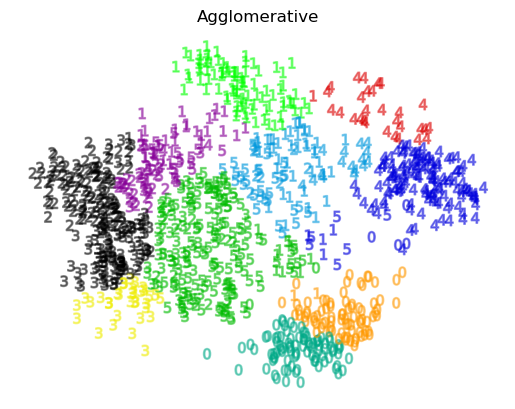

<Figure size 1200x1000 with 0 Axes>

In [55]:
agglom = AgglomerativeClustering(linkage='complete', n_clusters=10)
agglom.fit(pca_emb)
plot_embedding(pca_emb[:,:2],agglom.labels_,'Agglomerative')

#### [Kmeans](https://en.wikipedia.org/wiki/K-means_clustering)

Given a set of observations (x1, x2, ..., xn), where each observation is a ${\displaystyle d}$-dimensional real vector, k-means clustering aims to partition the n observations into k (≤ n) sets $S = {S1, S2, ..., Sk}$ so as to minimize the within-cluster sum of squares (WCSS) (i.e. variance). Formally, the objective is to find: 

${\displaystyle \mathop {\operatorname {arg\,min} } _{\mathbf {S} }\sum _{i=1}^{k}\sum _{\mathbf {x} \in S_{i}}\left\|\mathbf {x} -{\boldsymbol {\mu }}_{i}\right\|^{2}=\mathop {\operatorname {arg\,min} } _{\mathbf {S} }\sum _{i=1}^{k}|S_{i}|\operatorname {Var} S_{i}}$

where $\mu_i$ is the mean (also called centroid) of points, i.e. 

${\displaystyle {\boldsymbol {\mu _{i}}}={\frac {1}{|S_{i}|}}\sum _{\mathbf {x} \in S_{i}}\mathbf {x} ,  }$   ${\displaystyle |S_{i}|}$ is the size of ${\displaystyle S_{i}}$, and ${\displaystyle \|\cdot \|}$ is the usual $L2$ norm . This is equivalent to minimizing the pairwise squared deviations of points in the same cluster: 

${\displaystyle \mathop {\operatorname {arg\,min} } _{\mathbf {S} }\sum _{i=1}^{k}\,{\frac {1}{|S_{i}|}}\,\sum _{\mathbf {x} ,\mathbf {y} \in S_{i}}\left\|\mathbf {x} -\mathbf {y} \right\|^{2}}$

The equivalence can be deduced from the identity: 

${\textstyle |S_{i}|\sum _{\mathbf {x} \in S_{i}}\left\|\mathbf {x} -{\boldsymbol {\mu }}_{i}\right\|^{2}={\frac {1}{2}}\sum _{\mathbf {x} ,\mathbf {y} \in S_{i}}\left\|\mathbf {x} -\mathbf {y} \right\|^{2}}$ 

Since the total variance is constant, this is equivalent to maximizing the sum of squared deviations between points in different clusters (between-cluster sum of squares, BCSS)

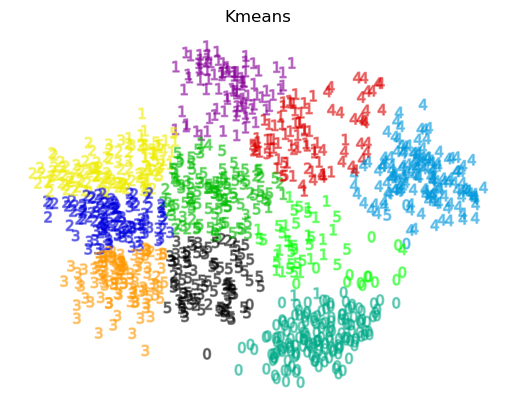

<Figure size 1200x1000 with 0 Axes>

In [58]:
kmeans = KMeans(init="k-means++", n_clusters=10, n_init=4)
kmeans.fit(pca_emb)
plot_embedding(pca_emb[:,:2],kmeans.labels_,'Kmeans')

#### <u>Exercises/Ideas</u>
##### (1) Run the T-SNE and UMAP dimensional reduction methods on the original X data and plot the Agglomerative/Kmeans clustering for each of those (total of 4 new plots)
##### (2) Try to produce a better T-SNE manifold by changing the plerplexity parameter (then cluster and check your results)
##### (3) Try to produce a better UMAP manifold by changing the minimum distance and the neirest neighbor parameters (then cluster and check your results)
##### (4) Which clustering method do you think works better?
##### (5) What makes a good dimension reduction for the MNIST data? Load another datset (like the CA housing datset or one from ISLP and see if that holds) ?